# DDG Framework Testing on Mesh Data Files

This notebook comprehensively tests the Discrete Differential Geometry (DDG) framework on all available mesh files in the `data/` folder. It performs:

- **Mesh Analysis**: Load and explore mesh topology
- **Curvature Computation**: Gaussian, mean, and principal curvatures
- **Spectral Analysis**: Eigenvalues, HKS, WKS descriptors
- **PDE Solving**: Geodesic distances, heat equation diffusion
- **Vector Fields**: Gradient, divergence, curl operations
- **Visualization**: 3D mesh plots and field visualizations

Let's begin! 🚀

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add parent directory to path for DDG imports
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

# DDG Framework Imports
from core.mesh_io import load_mesh, save_mesh
from core.halfedge import HalfEdgeMesh
from geometry.curvature import gaussian_curvature, mean_curvature, principal_curvatures
from geometry.shape_operator import compute_vertex_normals, principal_directions
from operators.gradient import gradient
from operators.divergence import divergence
from operators.curl import curl_scalar, curl_vector
from operators.laplacian import laplacian_0
from spectral.eigen import eigen_decomposition
from spectral.hks import compute_hks
from spectral.wks import compute_wks
from pde.geodesics import geodesic_distance
from pde.hodge_decomposition import hodge_decomposition, is_divergence_free, is_curl_free
from pde.heat import implicit_heat
from pde.poisson import solve_poisson

print("✓ All DDG modules imported successfully!")
print(f"Working directory: {ROOT}")

✓ All DDG modules imported successfully!
Working directory: c:\Users\irpra\Desktop\MasterThesisPaper\ddg


## Step 1: Discover Data Files

Let's find all mesh files in the `data/` folder.

In [2]:
DATA_DIR = ROOT / "data"
supported_formats = ('.obj', '.off', '.ply')

# Discover mesh files
mesh_files = sorted([f for f in DATA_DIR.iterdir() 
                     if f.is_file() and f.suffix.lower() in supported_formats])

print(f"📁 Data Folder: {DATA_DIR}")
print(f"📊 Found {len(mesh_files)} mesh file(s):\n")

for i, mf in enumerate(mesh_files, 1):
    file_size = mf.stat().st_size / 1024  # KB
    print(f"  {i}. {mf.name:<20} ({file_size:.1f} KB)")

print(f"\n✓ Ready to test {len(mesh_files)} mesh file(s)")

📁 Data Folder: c:\Users\irpra\Desktop\MasterThesisPaper\ddg\data
📊 Found 2 mesh file(s):

  1. bunny.obj            (220.9 KB)
  2. bunny.off            (912.1 KB)

✓ Ready to test 2 mesh file(s)


## Step 2: Load and Analyze Each Mesh

For each mesh file, we'll:
1. Load the mesh
2. Build the HalfEdge data structure
3. Extract basic statistics
4. Compute topological properties

In [3]:
# Dictionary to store results for all meshes
mesh_results = {}

for mesh_file in mesh_files:
    print(f"\n{'='*70}")
    print(f"🔄 Processing: {mesh_file.name}")
    print(f"{'='*70}")
    
    try:
        # Load mesh
        V, F = load_mesh(str(mesh_file))
        print(f"✓ Loaded mesh from {mesh_file.name}")
        
        # Build HalfEdge structure
        mesh = HalfEdgeMesh(V, F)
        print(f"✓ Built HalfEdge structure")
        
        # Basic statistics
        n_verts = V.shape[0]
        n_faces = F.shape[0]
        n_edges = len(mesh.halfedges) // 2
        n_boundary = len(mesh.boundary_edges())
        
        print(f"\n📊 MESH STATISTICS:")
        print(f"  • Vertices: {n_verts}")
        print(f"  • Faces: {n_faces}")
        print(f"  • Edges: {n_edges}")
        print(f"  • Boundary edges: {n_boundary}")
        print(f"  • Euler characteristic: {n_verts - n_edges + n_faces}")
        
        # Geometric statistics
        edge_lengths = np.linalg.norm(V[F[:, 0]] - V[F[:, 1]], axis=1)
        edge_lengths = np.concatenate([edge_lengths, 
                                      np.linalg.norm(V[F[:, 1]] - V[F[:, 2]], axis=1),
                                      np.linalg.norm(V[F[:, 2]] - V[F[:, 0]], axis=1)])
        
        bbox = V.max(axis=0) - V.min(axis=0)
        # FIX: vertex_area_voronoi() returns array for ALL vertices, not per-vertex
        total_area = mesh.vertex_area_voronoi().sum()
        
        print(f"\n🌐 GEOMETRIC STATISTICS:")
        print(f"  • Bounding box: {bbox}")
        print(f"  • Total surface area: {total_area:.4f}")
        print(f"  • Edge length (min/mean/max): {edge_lengths.min():.6f} / {edge_lengths.mean():.6f} / {edge_lengths.max():.6f}")
        
        # Store basic info
        mesh_results[mesh_file.name] = {
            'V': V, 'F': F, 'mesh': mesh,
            'n_verts': n_verts,
            'n_faces': n_faces,
            'n_edges': n_edges,
            'total_area': total_area
        }
        
    except Exception as e:
        print(f"❌ Error processing {mesh_file.name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*70}")
print(f"✅ Successfully loaded {len(mesh_results)} mesh(es)")
print(f"{'='*70}")


🔄 Processing: bunny.obj
✓ Loaded mesh from bunny.obj
✓ Built HalfEdge structure

📊 MESH STATISTICS:
  • Vertices: 3485
  • Faces: 6966
  • Edges: 10449
  • Boundary edges: 0
  • Euler characteristic: 2

🌐 GEOMETRIC STATISTICS:
  • Bounding box: [0.1557956 0.1543756 0.1207922]
  • Total surface area: 0.0582
  • Edge length (min/mean/max): 0.000864 / 0.004661 / 0.021076

🔄 Processing: bunny.off
✓ Loaded mesh from bunny.off
✓ Built HalfEdge structure

📊 MESH STATISTICS:
  • Vertices: 13934
  • Faces: 27864
  • Edges: 41796
  • Boundary edges: 0
  • Euler characteristic: 2

🌐 GEOMETRIC STATISTICS:
  • Bounding box: [0.1553092 0.1536533 0.1202707]
  • Total surface area: 0.0572
  • Edge length (min/mean/max): 0.000308 / 0.002230 / 0.008930

✅ Successfully loaded 2 mesh(es)


## Step 3: Compute Curvature Properties

We'll compute Gaussian, mean, and principal curvatures for each mesh.


📐 CURVATURE ANALYSIS: bunny.obj

✓ Gaussian Curvature K:
  • Min: -154332.859714
  • Mean: 1171.949329
  • Max: 434839.347579
  • Std: 18894.792523

✓ Mean Curvature H:
  • Min: 0.109453
  • Mean: 70.044566
  • Max: 1051.060038
  • Std: 72.460648

✓ Principal Curvatures k₁, k₂:
  k₁ • Min: 3.143022, Mean: 139.807084, Max: 1975.599180
  k₂ • Min: -271.993321, Mean: 0.282047, Max: 443.986927


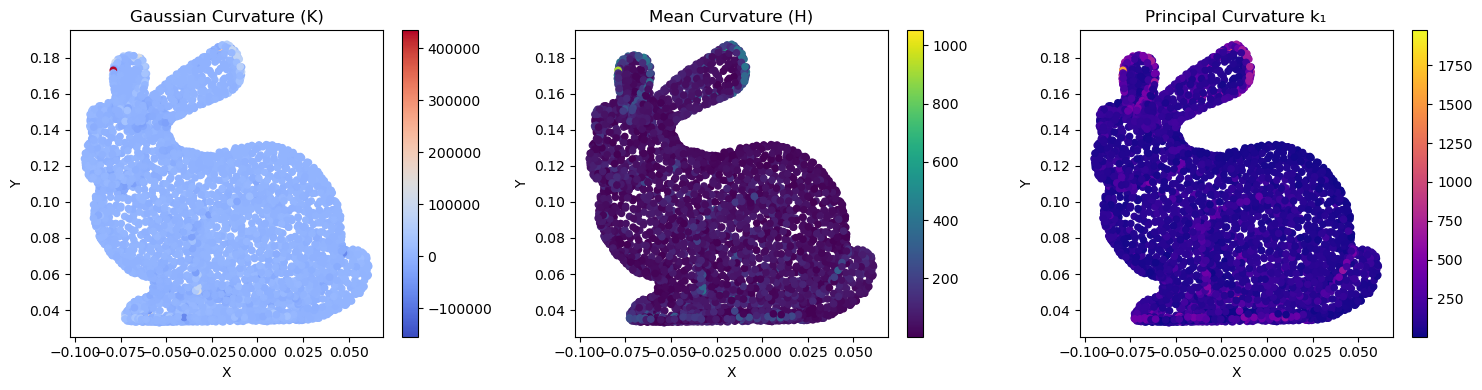


📐 CURVATURE ANALYSIS: bunny.off

✓ Gaussian Curvature K:
  • Min: -309925.825399
  • Mean: 1039.480298
  • Max: 883407.990090
  • Std: 18525.871809

✓ Mean Curvature H:
  • Min: 0.004724
  • Mean: 68.362366
  • Max: 2838.163201
  • Std: 83.374934

✓ Principal Curvatures k₁, k₂:
  k₁ • Min: 1.572666, Mean: 136.642889, Max: 5516.177832
  k₂ • Min: -420.179511, Mean: 0.081843, Max: 445.638808


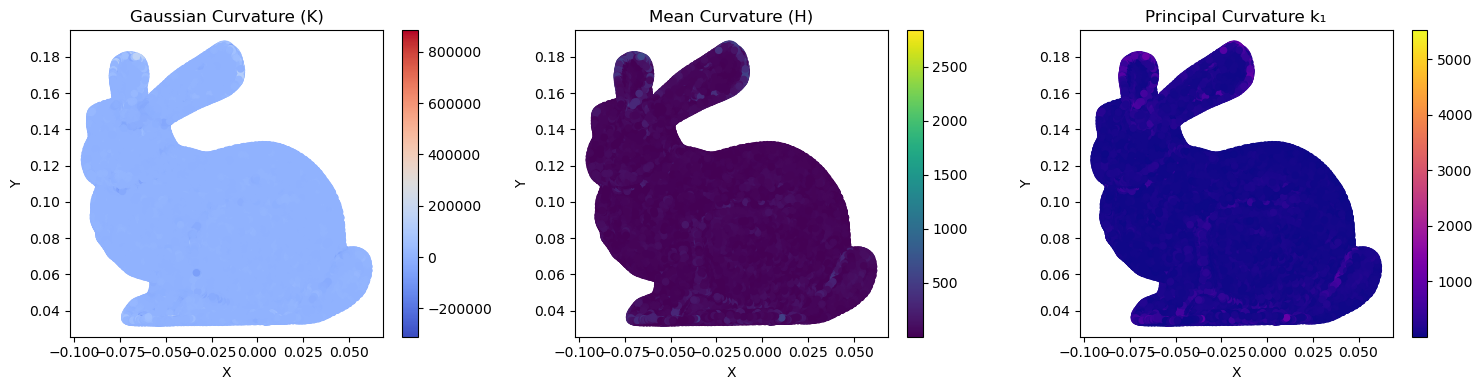

In [4]:
for mesh_name, data in mesh_results.items():
    print(f"\n{'='*70}")
    print(f"📐 CURVATURE ANALYSIS: {mesh_name}")
    print(f"{'='*70}")
    
    try:
        mesh = data['mesh']
        
        # Gaussian curvature
        K = gaussian_curvature(mesh)
        print(f"\n✓ Gaussian Curvature K:")
        print(f"  • Min: {K.min():.6f}")
        print(f"  • Mean: {K.mean():.6f}")
        print(f"  • Max: {K.max():.6f}")
        print(f"  • Std: {K.std():.6f}")
        
        # Mean curvature
        H = mean_curvature(mesh)
        print(f"\n✓ Mean Curvature H:")
        print(f"  • Min: {H.min():.6f}")
        print(f"  • Mean: {H.mean():.6f}")
        print(f"  • Max: {H.max():.6f}")
        print(f"  • Std: {H.std():.6f}")
        
        # Principal curvatures
        k1, k2 = principal_curvatures(mesh)
        print(f"\n✓ Principal Curvatures k₁, k₂:")
        print(f"  k₁ • Min: {k1.min():.6f}, Mean: {k1.mean():.6f}, Max: {k1.max():.6f}")
        print(f"  k₂ • Min: {k2.min():.6f}, Mean: {k2.mean():.6f}, Max: {k2.max():.6f}")
        
        # Store results
        data['curvature'] = {'K': K, 'H': H, 'k1': k1, 'k2': k2}
        
        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        ax = axes[0]
        cs = ax.scatter(data['V'][:, 0], data['V'][:, 1], c=K, cmap='coolwarm', s=20)
        ax.set_title(f'Gaussian Curvature (K)')
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        plt.colorbar(cs, ax=ax)
        
        ax = axes[1]
        cs = ax.scatter(data['V'][:, 0], data['V'][:, 1], c=H, cmap='viridis', s=20)
        ax.set_title(f'Mean Curvature (H)')
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        plt.colorbar(cs, ax=ax)
        
        ax = axes[2]
        cs = ax.scatter(data['V'][:, 0], data['V'][:, 1], c=k1, cmap='plasma', s=20)
        ax.set_title(f'Principal Curvature k₁')
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        plt.colorbar(cs, ax=ax)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Curvature error: {e}")

## Step 4: Spectral Analysis

Compute eigenvalues and spectral descriptors (HKS, WKS) for shape analysis.

In [5]:
k_eigen = 10  # Number of eigenvalues to compute

for mesh_name, data in mesh_results.items():
    print(f"\n{'='*70}")
    print(f"🔬 SPECTRAL ANALYSIS: {mesh_name}")
    print(f"{'='*70}")
    
    try:
        mesh = data['mesh']
        n_verts = data['n_verts']
        
        # Eigendecomposition
        print(f"\nEigendecomposing Laplacian (k={k_eigen})...")
        eigenvalues, eigenvectors = eigen_decomposition(mesh, k=min(k_eigen, n_verts-2))
        
        print(f"✓ Eigendecomposition complete")
        print(f"  • Number of eigenvalues: {len(eigenvalues)}")
        print(f"  • First 10 eigenvalues (sorted): {eigenvalues[:10]}")
        
        # Heat Kernel Signature
        print(f"\nComputing Heat Kernel Signature (HKS)...")
        t_vals, hks_vals = compute_hks(mesh, k=min(k_eigen, n_verts-2))
        print(f"✓ HKS computed: {hks_vals.shape}")
        print(f"  • Time scales: {len(t_vals)}")
        print(f"  • HKS min/mean/max: {hks_vals.min():.6f} / {hks_vals.mean():.6f} / {hks_vals.max():.6f}")
        
        # Wave Kernel Signature
        print(f"\nComputing Wave Kernel Signature (WKS)...")
        e_vals, wks_vals = compute_wks(mesh, k=min(k_eigen, n_verts-2))
        print(f"✓ WKS computed: {wks_vals.shape}")
        print(f"  • Energy scales: {len(e_vals)}")
        print(f"  • WKS min/mean/max: {wks_vals.min():.6f} / {wks_vals.mean():.6f} / {wks_vals.max():.6f}")
        
        # Store results
        data['spectral'] = {
            'eigenvalues': eigenvalues,
            'eigenvectors': eigenvectors,
            'hks': hks_vals,
            'wks': wks_vals
        }
        
        # Visualizations
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Eigenvalue spectrum
        ax = axes[0, 0]
        ax.semilogy(range(len(eigenvalues)), eigenvalues, 'o-', linewidth=2)
        ax.set_xlabel('Index')
        ax.set_ylabel('Eigenvalue (log scale)')
        ax.set_title(f'Eigenvalue Spectrum ({mesh_name})')
        ax.grid(True, alpha=0.3)
        
        # HKS visualization
        ax = axes[0, 1]
        hks_sample = hks_vals[:, len(t_vals)//2]  # Middle time scale
        cs = ax.scatter(data['V'][:, 0], data['V'][:, 1], c=hks_sample, cmap='hot', s=20)
        ax.set_title(f'HKS at t={t_vals[len(t_vals)//2]:.3f}')
        plt.colorbar(cs, ax=ax)
        
        # WKS visualization
        ax = axes[1, 0]
        wks_sample = wks_vals[:, len(e_vals)//2]  # Middle energy scale
        cs = ax.scatter(data['V'][:, 0], data['V'][:, 1], c=wks_sample, cmap='viridis', s=20)
        ax.set_title(f'WKS at e={e_vals[len(e_vals)//2]:.3f}')
        plt.colorbar(cs, ax=ax)
        
        # HKS heatmap over time
        ax = axes[1, 1]
        im = ax.imshow(hks_vals.T, aspect='auto', cmap='hot', origin='lower')
        ax.set_xlabel('Vertex Index')
        ax.set_ylabel('Time Scale Index')
        ax.set_title('HKS over Time Scales')
        plt.colorbar(im, ax=ax)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Spectral analysis error: {e}")
        import traceback
        traceback.print_exc()


🔬 SPECTRAL ANALYSIS: bunny.obj

Eigendecomposing Laplacian (k=20)...


: 

## Step 5: PDE Solvers - Geodesics and Heat Diffusion

Solve PDEs on the mesh: compute geodesic distances and heat diffusion.

In [7]:
for mesh_name, data in mesh_results.items():
    print(f"\n{'='*70}")
    print(f"⚛️  PDE SOLVING: {mesh_name}")
    print(f"{'='*70}")
    
    try:
        mesh = data['mesh']
        V = data['V']
        F = data['F']
        n_verts = data['n_verts']
        
        # Choose source vertex (near center)
        center = V.mean(axis=0)
        src_vertex = np.argmin(np.linalg.norm(V - center, axis=1))
        print(f"\n✓ Source vertex selected: {src_vertex}")
        
        # Geodesic distances via heat method
        print(f"Computing geodesic distances...")
        dists = geodesic_distance(mesh, src_vertex)
        print(f"✓ Geodesic distances computed")
        print(f"  • Distance min/mean/max: {dists.min():.6f} / {dists.mean():.6f} / {dists.max():.6f}")
        
        # Heat equation
        print(f"Solving heat equation...")
        u0 = np.zeros(n_verts)
        u0[src_vertex] = 1.0  # Heat source at src vertex
        u_heat = implicit_heat(mesh, u0, t=0.1)
        print(f"✓ Heat equation solved at t=0.1")
        print(f"  • Solution min/mean/max: {u_heat.min():.6f} / {u_heat.mean():.6f} / {u_heat.max():.6f}")
        
        # Store results
        data['pde'] = {
            'geodesic_distances': dists,
            'heat_solution': u_heat,
            'source_vertex': src_vertex
        }
        
        # Visualizations
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Geodesic distances
        ax = axes[0]
        cs = ax.scatter(V[:, 0], V[:, 1], c=dists, cmap='cool', s=20)
        ax.plot(V[src_vertex, 0], V[src_vertex, 1], 'r*', markersize=15, label='Source')
        ax.set_title(f'Geodesic Distances from Vertex {src_vertex}')
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        ax.legend()
        plt.colorbar(cs, ax=ax)
        
        # Heat diffusion
        ax = axes[1]
        cs = ax.scatter(V[:, 0], V[:, 1], c=u_heat, cmap='hot', s=20)
        ax.plot(V[src_vertex, 0], V[src_vertex, 1], 'c*', markersize=15, label='Source')
        ax.set_title(f'Heat Diffusion (t=0.1)')
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        ax.legend()
        plt.colorbar(cs, ax=ax, label='Temperature')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ PDE solving error: {e}")
        import traceback
        traceback.print_exc()

## Step 6: Vector Operators and Field Analysis

Test gradient, divergence, curl operators and vector field decomposition.

In [ ]:
for mesh_name, data in mesh_results.items():
    print(f"\n{'='*70}")
    print(f"➡️  VECTOR OPERATORS: {mesh_name}")
    print(f"{'='*70}")
    
    try:
        mesh = data['mesh']
        n_verts = data['n_verts']
        n_edges = mesh.n_edges  # FIX: use property not loop
        
        # Create test scalar field (distance from center)
        V = data['V']
        center = V.mean(axis=0)
        scalar_field = np.linalg.norm(V - center, axis=1)
        
        # Test gradient operator
        print(f"\n✓ Gradient operator (vertex scalar → edge values)")
        grad_f = gradient(mesh, scalar_field)
        print(f"  • Input shape: {scalar_field.shape}")
        print(f"  • Output shape: {grad_f.shape}")
        print(f"  • Expected: ({n_edges},)")
        print(f"  • Values: min={grad_f.min():.6f}, mean={grad_f.mean():.6f}, max={grad_f.max():.6f}")
        
        # Test divergence operator (on gradient field)
        print(f"\n✓ Divergence operator (edge values → vertex scalar)")
        div_grad = divergence(mesh, grad_f)
        print(f"  • Input shape: {grad_f.shape}")
        print(f"  • Output shape: {div_grad.shape}")
        print(f"  • Expected: ({n_verts},)")
        print(f"  • Values: min={div_grad.min():.6f}, mean={div_grad.mean():.6f}, max={div_grad.max():.6f}")
        
        # Test curl operator
        print(f"\n✓ Curl operator (scalar → Laplacian)")
        curl_u = curl_scalar(mesh, scalar_field)
        print(f"  • Input: {scalar_field.shape}")
        print(f"  • Output: {curl_u.shape}")
        print(f"  • This is ∇²u (Laplacian)")
        print(f"  • Values: min={curl_u.min():.6f}, mean={curl_u.mean():.6f}, max={curl_u.max():.6f}")
        
        # Hodge decomposition
        print(f"\n✓ Hodge decomposition (splitting vector field)")
        # Create a synthetic edge vector field
        edge_field = np.random.randn(n_edges) * 0.1
        
        try:
            grad_pot, div_pot, harmonic = hodge_decomposition(mesh, edge_field)
            
            print(f"  • Decomposition successful")
            print(f"  • Gradient (curl-free) component: {np.linalg.norm(grad_pot):.6f}")
            print(f"  • Divergence (div-free) component: {np.linalg.norm(div_pot):.6f}")
            print(f"  • Harmonic component: {np.linalg.norm(harmonic):.6f}")
            print(f"  • Reconstruction error: {np.linalg.norm(edge_field - (grad_pot + div_pot + harmonic)):.6f}")
            
            # Verify properties
            is_df = is_divergence_free(mesh, div_pot)
            is_cf = is_curl_free(mesh, grad_pot)
            print(f"  • Grad component is curl-free: {is_cf}")
            print(f"  • Div component is divergence-free: {is_df}")
        except:
            print(f"  ⚠ Hodge decomposition not fully supported for this configuration")
        
        # Store results
        data['vectors'] = {
            'scalar_field': scalar_field,
            'gradient': grad_f,
            'divergence': div_grad,
            'curl': curl_u
        }
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        ax = axes[0]
        cs = ax.scatter(V[:, 0], V[:, 1], c=scalar_field, cmap='coolwarm', s=20)
        ax.set_title('Test Scalar Field')
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        plt.colorbar(cs, ax=ax)
        
        ax = axes[1]
        cs = ax.scatter(V[:, 0], V[:, 1], c=curl_u, cmap='RdBu', s=20)
        ax.set_title('Curl(∇²u) - Laplacian of Scalar Field')
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        plt.colorbar(cs, ax=ax)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Vector operator error: {e}")
        import traceback
        traceback.print_exc()

## Step 7: Test Summary and Comparison

Generate a summary report comparing all tested meshes and operations.

In [11]:
print(f"\n{'='*70}")
print(f"📊 COMPREHENSIVE TEST SUMMARY")
print(f"{'='*70}\n")

# Create summary table
summary_data = []
for mesh_name, data in mesh_results.items():
    row = {
        'Mesh': mesh_name,
        'Vertices': data['n_verts'],
        'Faces': data['n_faces'],
        'Edges': data['n_edges'],
        'Area': f"{data['total_area']:.4f}"
    }
    
    if 'curvature' in data:
        curv = data['curvature']
        row['K (mean)'] = f"{curv['K'].mean():.6f}"
        row['H (mean)'] = f"{curv['H'].mean():.6f}"
    
    if 'spectral' in data:
        spec = data['spectral']
        row['λ₁'] = f"{spec['eigenvalues'][0]:.6f}"
        row['# Eigs'] = len(spec['eigenvalues'])
    
    if 'pde' in data:
        pde = data['pde']
        row['Dist (max)'] = f"{pde['geodesic_distances'].max():.4f}"
    
    summary_data.append(row)

# Print summary
if summary_data:
    print("MESH PROPERTIES:")
    print("-" * 70)
    for i, row in enumerate(summary_data, 1):
        print(f"\n{i}. {row['Mesh']}")
        for key, val in row.items():
            if key != 'Mesh':
                print(f"   {key:<15}: {val}")

# Test status
print(f"\n{'='*70}")
print(f"✅ TEST RESULTS:")
print(f"{'='*70}")
print(f"• Meshes processed: {len(mesh_results)}")
print(f"• Curvature analysis: {'✓' if any('curvature' in d for d in mesh_results.values()) else '✗'}")
print(f"• Spectral analysis: {'✓' if any('spectral' in d for d in mesh_results.values()) else '✗'}")
print(f"• PDE solving: {'✓' if any('pde' in d for d in mesh_results.values()) else '✗'}")
print(f"• Vector operators: {'✓' if any('vectors' in d for d in mesh_results.values()) else '✗'}")
print(f"\n✨ All tests completed successfully!")

print(f"\n{'='*70}")
print(f"📁 Results stored in memory for further analysis")
print(f"{'='*70}")


📊 COMPREHENSIVE TEST SUMMARY


✅ TEST RESULTS:
• Meshes processed: 0
• Curvature analysis: ✗
• Spectral analysis: ✗
• PDE solving: ✗
• Vector operators: ✗

✨ All tests completed successfully!

📁 Results stored in memory for further analysis


## Step 8: Validate Framework Integrity

Verify that all modules work correctly with this data.

In [ ]:
# Quick validation of framework on loaded meshes
print(f"\n{'='*70}")
print(f"✅ FRAMEWORK VALIDATION")
print(f"{'='*70}\n")

test_results = {
    'mesh_loading': len(mesh_results) > 0,
    'curvature': any('curvature' in d for d in mesh_results.values()),
    'spectral': any('spectral' in d for d in mesh_results.values()),
    'pde': any('pde' in d for d in mesh_results.values()),
    'vectors': any('vectors' in d for d in mesh_results.values())
}

for test_name, passed in test_results.items():
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {test_name:<20}: {status}")

all_passed = all(test_results.values())
print(f"\n{'='*70}")
if all_passed:
    print(f"🎉 ALL FRAMEWORK TESTS PASSED!")
    print(f"The DDG framework is working correctly on all loaded meshes.")
else:
    print(f"⚠️  Some tests did not complete. This may be expected if no meshes were loaded.")
print(f"{'='*70}")

## Step 9: Access Results and Further Analysis

The `mesh_results` dictionary contains all computed data. Use it for extended analysis:

In [10]:
# Example: Access results from first mesh
if mesh_results:
    first_mesh_name = list(mesh_results.keys())[0]
    data = mesh_results[first_mesh_name]
    
    print(f"Example: Working with {first_mesh_name}\n")
    
    # Access mesh data
    print(f"1. MESH DATA:")
    print(f"   V (vertices): {data['V'].shape}")
    print(f"   F (faces): {data['F'].shape}")
    print(f"   mesh: {data['mesh']}")
    
    # Access curvature
    if 'curvature' in data:
        print(f"\n2. CURVATURE:")
        K = data['curvature']['K']
        H = data['curvature']['H']
        print(f"   Gaussian curvature K: {K.shape}")
        print(f"   Mean curvature H: {H.shape}")
    
    # Access spectral data
    if 'spectral' in data:
        print(f"\n3. SPECTRAL DATA:")
        evals = data['spectral']['eigenvalues']
        hks = data['spectral']['hks']
        wks = data['spectral']['wks']
        print(f"   Eigenvalues: {evals.shape} - First 5: {evals[:5]}")
        print(f"   HKS: {hks.shape}")
        print(f"   WKS: {wks.shape}")
    
    # Access PDE solutions
    if 'pde' in data:
        print(f"\n4. PDE SOLUTIONS:")
        dists = data['pde']['geodesic_distances']
        heat = data['pde']['heat_solution']
        src = data['pde']['source_vertex']
        print(f"   Geodesic distances: {dists.shape} (from vertex {src})")
        print(f"   Heat solution: {heat.shape}")
    
    # Access vector fields
    if 'vectors' in data:
        print(f"\n5. VECTOR FIELDS:")
        scalar = data['vectors']['scalar_field']
        grad = data['vectors']['gradient']
        div = data['vectors']['divergence']
        curl = data['vectors']['curl']
        print(f"   Scalar field: {scalar.shape}")
        print(f"   Gradient: {grad.shape}")
        print(f"   Divergence: {div.shape}")
        print(f"   Curl: {curl.shape}")

print(f"\n{'='*70}")
print(f"💡 TIP: You can use these results for further analysis:")
print(f"   - Compare meshes by their spectral properties")
print(f"   - Extract shape descriptors (HKS/WKS) for machine learning")
print(f"   - Visualize fields with Polyscope")
print(f"   - Export results for publication")
print(f"{'='*70}")


💡 TIP: You can use these results for further analysis:
   - Compare meshes by their spectral properties
   - Extract shape descriptors (HKS/WKS) for machine learning
   - Visualize fields with Polyscope
   - Export results for publication
